# **Lab 6. LiDAR - 3D Point Cloud Combine & Real-Time Plane Segmentation**

**Hardware:** Livox MID-70 (3D LiDAR)  
**Platform:** Ubuntu 22.04 + ROS 2 Humble  
**Teamwork:** 4 Teams at all!!

## **Objectives**

* Connect the **Livox MID-70** to ROS 2 and visualize 3D point clouds in RViz2
* Capture multiple LiDAR snapshots from different positions in a room
* Implement the **ICP (Iterative Closest Point)** algorithm from scratch using NumPy
* Combine multiple point clouds into a single 3D map of the room
* Compare your ICP implementation with **Open3D**'s built-in ICP
* Detect **walls and floor** in real-time using **RANSAC** plane segmentation
* Publish segmentation results as colored markers in RViz2

## **Hardware**

* Livox MID-70 LiDAR sensor
* Livox Converter 2.0 (power + Ethernet interface)
* Conversion cable (M12 aviation connector to Converter 2.0)
* Ethernet cable (Converter 2.0 to PC)
* External power supply: 9–30 V via Converter 2.0
* Your laptop with an Ethernet port (or USB-Ethernet adapter)

### [Livox MID-70 Specs](https://www.livoxtech.com/mid-70)

| Parameter | Value |
|---|---|
| FOV | 70.4° circular |
| Range | 260 m (@ 80% reflectivity) |
| Point rate | 100,000 pts/s |
| Scan pattern | Non-repetitive (coverage grows over time) |
| Interface | Ethernet (UDP) |


> **Key feature:** Unlike spinning LiDARs (e.g. Velodyne), the MID-70 uses a non-repetitive scan pattern. This means that if you hold the LiDAR stationary for ~10–15 seconds, it accumulates a very dense point cloud covering the entire FOV - almost like taking a "photo" in 3D.

Cloud coverage example in 4 periods of time:


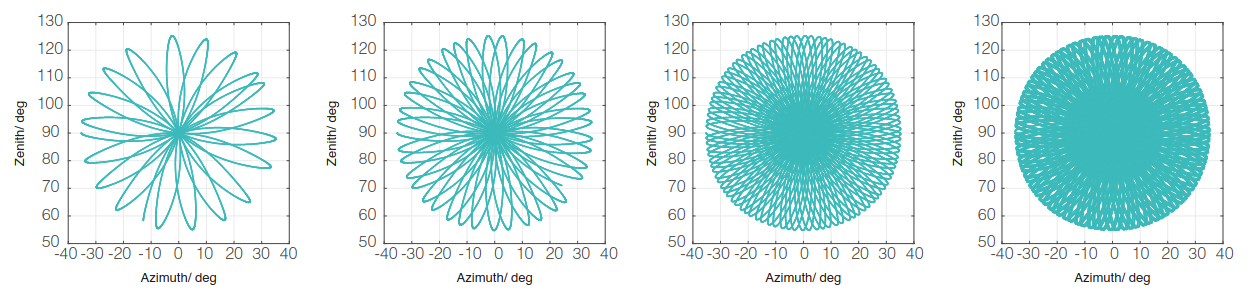

## **Software**

Special Docker container with:
* **ROS 2 Humble** (Desktop-Full)
* **Livox-SDK** (v1, for MID-70) + **livox_ros2_driver** (community fork for Humble)
* **Open3D** - point cloud processing and visualization
* **NumPy**, **SciPy** - for implementing ICP from scratch
* **RViz2** - real-time visualization

### Useful Links

* [Livox MID-70 User Manual (PDF)](https://terra-1-g.djicdn.com/65c028cd298f4669a7f0e40e50ba1131/Download/Mid-70/new/Livox%20Mid-70%20User%20Manual_EN_v1.2.pdf)
* [Livox-SDK (v1) GitHub](https://github.com/Livox-SDK/Livox-SDK)
* [livox_ros2_driver for Humble (community fork)](https://github.com/silolytics/livox_ros2_driver_humble)
* [Open3D ICP Tutorial](https://www.open3d.org/docs/release/tutorial/pipelines/icp_registration.html)
* [Open3D Plane Segmentation](https://www.open3d.org/docs/release/tutorial/geometry/pointcloud.html#Plane-segmentation)

## **Task 1. Hardware Connection & Driver Setup**

#### All following work should be in container:

### 1.1 Connect the MID-70

[User manual](https://terra-1-g.djicdn.com/65c028cd298f4669a7f0e40e50ba1131/Download/Mid-70/new/Livox%20Mid-70%20User%20Manual_EN_v1.2.pdf)

1. Connect the MID-70 to the **Livox Converter 2.0** via the conversion cable (M12 aviation connector)
2. Connect the Converter 2.0 to your PC via **Ethernet cable**
3. Connect the Converter 2.0 to the **external power supply** (9-30 V DC)
4. The MID-70 LED should start blinking and LiDAR starts buzzing - the sensor is booting

### 1.2 Configure the network

The MID-70 uses a **static IP** by default: `192.168.123.1XX` (where XX = last 2 digits of the serial number printed on the sensor body).

Set your PC's Ethernet interface to a static IP in the same subnet by your own or through special script in lab files:

```bash
sudo ROBOT_IP=<livox lidar ip> HOST_IP_CIDR=<your pc static ip in the same network, e.g: 192.168.123.10/24> ~/ros2_ws/src/set_livox_connection.sh
```

You should see something like:

`Done. You can now use this interface to talk to the Livox Mid-70`


> **Tip:** If you need to use Wi-Fi, the Ethernet and Wi-Fi interfaces can coexist on different subnets without conflict.


### 1.3 Configure the driver

Edit the JSON config file to match your sensor's broadcast code inside container:

```bash
nano ~/livox_ws/src/livox_ros2_driver_humble/livox_ros2_driver/config/livox_lidar_config.json
```

Set `"enable_connect"` to `true` with your own `lidar_config`. You can determine your lidar by `broadcast_code` which is consist of S/N and numver `1` at the end

Build pkgs:
```bash
cd ~/livox_ws/
colcon build
source install/setup.bash
cd ~/ros2_ws/
```

### 1.4 Launch and verify in RViz2

```bash
# Terminal 1: Launch the driver
ros2 launch livox_ros2_driver livox_lidar_rviz_launch.py
```

In RViz2 (in no data):
1. Set **Fixed Frame** to `livox_frame`
2. Add a **PointCloud2** display
3. Set the topic to `/livox/lidar`
4. Set **Size** to `0.01` and **Color Transformer** to `Intensity` or `FlatColor`

You should see a point cloud that gradually fills in the scene as the non-repetitive scan pattern covers the FOV.

> *tip:* try to increase `Decay Time` in `PointCloud2` menu

Check available topics:
```bash
ros2 topic list
ros2 topic hz /livox/lidar   # Should show ~10 Hz
```

**Checkpoint (report):** Screenshot of the live point cloud in RViz2.

---

## **Task 2. Build a 3D Map of the Room Using ICP**

### Overview

In this task, you will:
1. Capture 2+ LiDAR "snapshots" from different positions in the room
2. Implement **ICP from scratch** (NumPy + SciPy) and stitch the clouds together
3. Repeat the stitching using **Open3D's ICP** and compare the results
4. Publish the final combined point cloud to RViz2

### Why ICP?

The **Iterative Closest Point** algorithm finds the optimal rigid transformation (rotation + translation) that aligns one point cloud to another. It works by:
1. Finding the **nearest neighbor** in the target cloud for each point in the source cloud
2. Computing the **optimal rotation and translation** (using SVD) that minimizes the sum of squared distances
3. Applying the transformation and **repeating** until convergence

This is the foundational algorithm behind most 3D mapping and SLAM systems.

### 2.1 Capture LiDAR Snapshots

[rosbag docs](https://docs.ros.org/en/humble/Tutorials/Beginner-CLI-Tools/Recording-And-Playing-Back-Data/Recording-And-Playing-Back-Data.html)


For this task we use Ros2 bags. ROS Bag (rosbag) is a built-in ROS2 tool for recording and replaying messages from topics. It saves all messages (with precise timestamps) to a file, and can then play them back as if the sensor were running live.

---



Choose a room where **at least 2 walls** are visible from each position.

For each position (minimum **2 positions**):

1. Place the LiDAR on a stable surface (tripod recommended)
2. Wait **~10 seconds** with recording for the non-repetitive pattern to fill the FOV:

Record for ~10 seconds, then press `Ctrl+C`:
```bash
ros2 bag record -o snapshot_<paste number> /livox/lidar
```

Or use timeout to stop automatically:
```bash
timeout 10 ros2 bag record -o snapshot_<paste number> /livox/lidar
```

4. Move the LiDAR to the next position (translate by ~1–2 meters, try to keep some overlap near 40-60%)
5. Repeat for positions 2, 3

Verify your recording:
```bash
ros2 bag info snapshot_1/
```
Should show `/livox/lidar` with type `sensor_msgs/msg/PointCloud2` and ~100 messages for 10 seconds at 10 Hz

> **Important:** Ensure significant **overlap** between snapshots — at least 30% of the scene should be visible from both positions. Overlapping walls, corners, and furniture are the features ICP uses for alignment.

### 2.2 Extract point clouds from rosbags

Write a Python script (or ROS 2 node) that:
1. Reads a rosbag file
2. Accumulates all PointCloud2 messages from one snapshot into a single dense point cloud
3. Saves the result as a `.ply` file

Helpful code for converting `PointCloud2` to numpy:


In [ ]:
import numpy as np
import struct
from pathlib import Path
from rosbags.typesys import Stores, get_typestore
from rosbags.highlevel import AnyReader
import open3d as o3d


def msg_to_numpy(msg):
    """Convert a deserialized PointCloud2 message to an Nx3 numpy array."""
    field_map = {f.name: f for f in msg.fields}
    if "x" not in field_map:
        return np.empty((0, 3))

    ox, oy, oz = field_map["x"].offset, field_map["y"].offset, field_map["z"].offset
    step = msg.point_step
    data = bytes(msg.data)
    n = msg.width * msg.height

    points = np.empty((n, 3), dtype=np.float32)
    for i in range(n):
        base = i * step
        points[i, 0] = struct.unpack_from("<f", data, base + ox)[0]
        points[i, 1] = struct.unpack_from("<f", data, base + oy)[0]
        points[i, 2] = struct.unpack_from("<f", data, base + oz)[0]

    valid = np.isfinite(points).all(axis=1) & (np.linalg.norm(points, axis=1) > 0.1)
    return points[valid].astype(np.float64)


def extract_bag(bag_path, topic="/livox/lidar"):
    """Read all PointCloud2 messages from a bag and return accumulated points."""
    typestore = get_typestore(Stores.ROS2_HUMBLE)
    all_points = []
    with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:
        conns = [c for c in reader.connections if c.topic == topic]
        for conn, timestamp, rawdata in reader.messages(connections=conns):
            msg = reader.deserialize(rawdata, conn.msgtype)
            pts = msg_to_numpy(msg)
            if len(pts) > 0:
                all_points.append(pts)
    return np.vstack(all_points) if all_points else np.empty((0, 3))

# === Save as .ply ===

def save_cloud(points, filename):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    o3d.io.write_point_cloud(filename, pcd)
    print(f"Saved {len(points)} points to {filename}")

# If you want to work in ROS2 fully
# from sensor_msgs_py import point_cloud2
def pc2_to_numpy(msg):
    points = []
    for p in point_cloud2.read_points(msg, field_names=('x', 'y', 'z'), skip_nans=True):
        points.append([p[0], p[1], p[2]])
    return np.array(points, dtype=np.float64)

### 2.3 Preprocess the point clouds

Before running ICP, apply preprocessing to reduce noise and computation time:

```python
import open3d as o3d

pcd = o3d.io.read_point_cloud("snapshot_1.ply")

# Voxel Downsampling divides the entire 3D space into a uniform grid of small
# cubes (voxels) with a given side length (in this case 5 cm). All points that
# fall within the same voxel are replaced by a single point at their centroid.
# This reduces the number of points while preserving the overall
# geometric shape of the scene. Smaller voxel_size keeps more detail but is
# slower to process; larger values are faster but lose fine features.
pcd_down = pcd.voxel_down_sample(voxel_size=0.05)  # 5 cm voxels


# Statistical Outlier Removal identifies and removes isolated noisy points
# that  don't belong to any real surface. For each point, it computes the mean
# distance to its nb_neighbors (nearest neighbors, here 20). If that mean
# distance is more than std_ratio (standard deviations, here 2.0) above the
# global average, the point is considered an outlier and removed. This
# effectively cleans up stray points caused by reflections, dust, sensor noise,
# or multi-path interference - all of which are common with solid-state LiDARs
# like the MID-70.
pcd_clean, ind = pcd_down.remove_statistical_outlier(
    nb_neighbors=20, std_ratio=2.0)


# Normal Estimation computes a surface normal vector for each point by fitting
# a local plane to its neighborhood. The KDTreeSearchParamHybrid defines how
# neighbors are selected: it considers points within a radius of 10 cm and caps
# the count at max_nn=30, whichever is more restrictive. The resulting normals
# are essential for Point-to-Plane ICP, which uses the normal direction to
# constrain how each point should "slide" onto the target surface — this is
# what makes it converge significantly faster than the basic Point-to-Point variant.
pcd_clean.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

print(f"Original: {len(pcd.points)} \n Processed: {len(pcd_clean.points)} points")
```

> *note:* A 10-second MID-70 capture at 100k pts/s yields ~1M points. Running ICP on the full cloud would take much time. Downsampling to ~50k points makes ICP run in seconds while preserving structural features.

### 2.4 Implement ICP from scratch (NumPy)

Implement the **point-to-point ICP** algorithm. Your implementation must include:

1. **Nearest neighbor search** using `scipy.spatial.KDTree`
2. **SVD-based optimal transformation** computation
3. **Iterative refinement** loop with convergence check

Links:

- [Original article of ICP](https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://graphics.stanford.edu/courses/cs164-09-spring/Handouts/paper_icp.pdf&ved=2ahUKEwjKhc_PxYuTAxUVR0EAHVHCANYQFnoECBoQAQ&usg=AOvVaw251UfODd_94GXfawVMAMkL)
- [Open3D docs](https://www.open3d.org/docs/latest/tutorial/pipelines/icp_registration.html)
- [Cool SVD-method description with animations by Arun, Huang & Blostein ;)](https://jingnanshi.com/blog/arun_method_for_3d_reg.html)
- [Article 'Least-Squares Fitting of Two 3-D Point Sets' by Arun, Huang & Blostein](https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://scispace.com/pdf/least-squares-fitting-of-two-3-d-point-sets-520ntlvg1b.pdf&ved=2ahUKEwj88cDmxouTAxUPUEEAHUkaJaoQFnoECB4QAQ&usg=AOvVaw0k2k4yz1isuw6vo20Kx8d1)
- [sensor_msgs/PointCloud2 Message](https://docs.ros.org/en/humble/p/sensor_msgs/msg/PointCloud2.html)
- [More detailed about sensor_msgs/PointCloud2 Message](https://medium.com/@tonyjacob_/pointcloud2-message-explained-853bd9907743)

Here is the skeleton - fill in the missing parts:

In [ ]:
import numpy as np
from scipy.spatial import KDTree


def find_correspondences(source_points, target_tree, max_dist):
    """
    For each point in source, find the nearest neighbor in target.

    Args:
        source_points: (N, 3) array
        target_tree: KDTree built from target points
        max_dist: maximum correspondence distance

    Returns:
        src_idx: indices of source points with valid correspondences
        tgt_idx: indices of corresponding target points
    """
    distances, indices = target_tree.query(source_points)
    valid = np.isfinite(distances) & (distances <= max_dist)
    src_idx = np.where(valid)[0]
    tgt_idx = indices[valid]
    return src_idx, tgt_idx


def compute_rigid_transform(src_points, tgt_points):
    """
    Compute optimal rotation R and translation t using SVD.
    Minimizes: sum ||R @ src_i + t - tgt_i||^2

    Args:
        src_points: (M, 3) matched source points
        tgt_points: (M, 3) matched target points

    Returns:
        R: (3, 3) rotation matrix
        t: (3,) translation vector
    """
    # Step 1: Compute centroids
    centroid_src = np.mean(src_points, axis=0)
    centroid_tgt = np.mean(tgt_points, axis=0)

    # Step 2: Center the points
    src_centered = src_points - centroid_src
    tgt_centered = tgt_points - centroid_tgt

    # Step 3: Compute cross-covariance matrix H
    H = src_centered.T @ tgt_centered

    # Step 4: SVD of H
    U, S, Vt = np.linalg.svd(H)

    # Step 5: Compute rotation R = V @ U^T
    # Handle reflection case: if det(R) < 0, flip sign of last column of V
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1.0
        R = Vt.T @ U.T

    # Step 6: Compute translation
    t = centroid_tgt - R @ centroid_src

    return R, t


def icp(source, target, max_iterations=50, tolerance=1e-6, max_correspondence_dist=0.5):
    """
    Point-to-point ICP algorithm.

    Args:
        source: (N, 3) source point cloud
        target: (M, 3) target point cloud
        max_iterations: maximum number of ICP iterations
        tolerance: convergence threshold (change in mean error)
        max_correspondence_dist: max distance for valid correspondences

    Returns:
        T: (4, 4) final transformation matrix
        errors: list of mean errors per iteration
    """
    src = source.copy()
    target_tree = KDTree(target)

    T_total = np.eye(4)
    errors = []

    for i in range(max_iterations):
        # Step 1: Find correspondences
        src_idx, tgt_idx = find_correspondences(src, target_tree, max_correspondence_dist)

        if len(src_idx) < 3:
            print(f"Stopped: not enough correspondences ({len(src_idx)})")
            break

        matched_src = src[src_idx]
        matched_tgt = target[tgt_idx]

        # Step 2: Compute transformation
        R, t = compute_rigid_transform(matched_src, matched_tgt)

        # Step 3: Apply transformation to source
        src = (R @ src.T).T + t

        # Step 4: Accumulate transformation
        T_inc = np.eye(4)
        T_inc[:3, :3] = R
        T_inc[:3, 3] = t
        T_total = T_inc @ T_total

        # Step 5: Compute mean error and check convergence
        transformed_matched = (R @ matched_src.T).T + t
        mean_error = np.mean(np.linalg.norm(transformed_matched - matched_tgt, axis=1))
        errors.append(mean_error)

        print(f"iter={i+1:02d}  pairs={len(src_idx):6d}  mean_error={mean_error:.6f}")

        if len(errors) > 1 and abs(errors[-2] - errors[-1]) < tolerance:
            print(f"Converged at iteration {i+1}")
            break

    return T_total, errors

# Usage:
# T, errors = icp(source_points, target_points)
# aligned_source = (T[:3, :3] @ source_points.T).T + T[:3, 3]


### 2.5 Register point clouds using Open3D ICP

Now repeat the registration using Open3D. Compare **two variants**:

```python
import open3d as o3d
import numpy as np

source = o3d.io.read_point_cloud("snapshot_1_processed.ply")
target = o3d.io.read_point_cloud("snapshot_2_processed.ply")

# Variant 1: Point-to-Point ICP
result_p2p = o3d.pipelines.registration.registration_icp(
    source, target,
    max_correspondence_distance=0.5,
    init=np.eye(4),
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint())

print(f"Point-to-Point: fitness={result_p2p.fitness:.4f}, RMSE={result_p2p.inlier_rmse:.4f}")

# Variant 2: Point-to-Plane ICP (requires normals)
result_p2l = o3d.pipelines.registration.registration_icp(
    source, target,
    max_correspondence_distance=0.5,
    init=np.eye(4),
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane())

print(f"Point-to-Plane: fitness={result_p2l.fitness:.4f}, RMSE={result_p2l.inlier_rmse:.4f}")
```

> **fitness** = ratio of inlier correspondences / total source points. Values close to 1.0 are good.

> **inlier_rmse** = RMSE of inlier correspondences in meters. Lower is better.

### 2.6 Stitch all snapshots into a single 3D map

Register clouds **pairwise** and accumulate transformations:


Color each cloud differently (e.g., red/green/blue) and merge:

```python
colors = [[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 0]]  # RGB
combined = o3d.geometry.PointCloud()

for i, cloud in enumerate(aligned_clouds):
    cloud.paint_uniform_color(colors[i % len(colors)])
    combined += cloud

o3d.visualization.draw_geometries([combined])
o3d.io.write_point_cloud("room_map_3d.ply", combined)
```

### 2.7 Publish the combined map in RViz2

Write a simple ROS 2 node that:
1. Loads the combined `.ply` file
2. Publishes it as a `sensor_msgs/PointCloud2` message on topic `/map_3d`
3. Uses `livox_frame` or `map` as the `frame_id`

Visualize in RViz2 with **Color Transformer set to RGB8** to see the color-coded origins.

**Checkpoint (report):**
* Screenshot of the combined 3D map in RViz2 (color-coded by position)
* Comparison table: Your ICP vs. Open3D Point-to-Point vs. Open3D Point-to-Plane
  * Metrics: number of iterations to converge, RMSE, fitness, execution time
* Convergence plot: RMSE vs. iteration number for each method

### 2.2 – 2.6 Full pipeline: extract → preprocess → ICP → stitch

In [ ]:
import time
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BAG_DIR   = Path("bag_files")
PLY_DIR   = Path("processed_clouds")
PLY_DIR.mkdir(exist_ok=True)

# Names for the two snapshots
SNAPSHOTS = ["snapshot_1", "snapshot_2"]
RAW_PLY   = [PLY_DIR / f"{s}.ply"       for s in SNAPSHOTS]
CLEAN_PLY = [PLY_DIR / f"{s}_clean.ply" for s in SNAPSHOTS]

# ── 2.2 Extract bags → raw .ply ────────────────────────────────────────────
for snap, raw_path in zip(SNAPSHOTS, RAW_PLY):
    bag_path = BAG_DIR / snap
    print(f"\nExtracting {bag_path} ...")
    pts = extract_bag(str(bag_path))          # from cell above
    save_cloud(pts, str(raw_path))

# ── 2.3 Preprocess: voxel downsample + outlier removal + normals ───────────
def preprocess(raw_path, clean_path, voxel_size=0.05):
    pcd = o3d.io.read_point_cloud(str(raw_path))
    print(f"Loaded {len(pcd.points)} pts from {raw_path}")
    pcd = pcd.voxel_down_sample(voxel_size)
    pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    o3d.io.write_point_cloud(str(clean_path), pcd)
    print(f"Preprocessed → {len(pcd.points)} pts  saved to {clean_path}")
    return pcd

pcds = [preprocess(r, c) for r, c in zip(RAW_PLY, CLEAN_PLY)]

# ── 2.4 NumPy ICP ──────────────────────────────────────────────────────────
src_pts = np.asarray(pcds[0].points)
tgt_pts = np.asarray(pcds[1].points)

print("\nRunning NumPy ICP ...")
t0 = time.time()
T_numpy, errors_numpy = icp(src_pts, tgt_pts,
                             max_iterations=50,
                             tolerance=1e-6,
                             max_correspondence_dist=0.3)
dt_numpy = time.time() - t0

print(f"\nNumPy ICP: {len(errors_numpy)} iters, "
      f"final RMSE={errors_numpy[-1]:.6f}, time={dt_numpy:.2f}s")
print("T =\n", T_numpy)

# Convergence plot
plt.figure(figsize=(7, 4))
plt.plot(errors_numpy, marker="o")
plt.xlabel("Iteration"); plt.ylabel("Mean error (m)")
plt.title("NumPy ICP convergence"); plt.grid(True)
plt.tight_layout(); plt.savefig("numpy_icp_convergence.png", dpi=150)
plt.show()

# ── 2.5 Open3D ICP (point-to-point and point-to-plane) ────────────────────
source_o3d = o3d.io.read_point_cloud(str(CLEAN_PLY[0]))
target_o3d = o3d.io.read_point_cloud(str(CLEAN_PLY[1]))

# Point-to-Point
t1 = time.time()
res_p2p = o3d.pipelines.registration.registration_icp(
    source_o3d, target_o3d,
    max_correspondence_distance=0.3,
    init=np.eye(4),
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint())
dt_p2p = time.time() - t1
print(f"\nOpen3D P2P:  fitness={res_p2p.fitness:.4f}  RMSE={res_p2p.inlier_rmse:.6f}  time={dt_p2p:.2f}s")

# Point-to-Plane
if not source_o3d.has_normals():
    source_o3d.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
if not target_o3d.has_normals():
    target_o3d.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

t2 = time.time()
res_p2l = o3d.pipelines.registration.registration_icp(
    source_o3d, target_o3d,
    max_correspondence_distance=0.3,
    init=np.eye(4),
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane())
dt_p2l = time.time() - t2
print(f"Open3D P2L:  fitness={res_p2l.fitness:.4f}  RMSE={res_p2l.inlier_rmse:.6f}  time={dt_p2l:.2f}s")

# ── Comparison table ────────────────────────────────────────────────────────
print("\n{'Method':<25} {'Iterations':>12} {'RMSE':>10} {'Fitness':>10} {'Time(s)':>10}")
print("-" * 70)
print(f"{'NumPy ICP (P2P)':<25} {len(errors_numpy):>12} {errors_numpy[-1]:>10.6f} {'N/A':>10} {dt_numpy:>10.2f}")
print(f"{'Open3D P2P':<25} {'N/A':>12} {res_p2p.inlier_rmse:>10.6f} {res_p2p.fitness:>10.4f} {dt_p2p:>10.2f}")
print(f"{'Open3D P2L':<25} {'N/A':>12} {res_p2l.inlier_rmse:>10.6f} {res_p2l.fitness:>10.4f} {dt_p2l:>10.2f}")

# ── 2.6 Stitch: apply best transform and merge ─────────────────────────────
# Use Open3D P2L result (usually best quality)
T_best = res_p2l.transformation

aligned_src = np.asarray(source_o3d.points)
aligned_src = (T_best[:3, :3] @ aligned_src.T).T + T_best[:3, 3]

pcd_aligned = o3d.geometry.PointCloud()
pcd_aligned.points = o3d.utility.Vector3dVector(aligned_src)

colors = [[1, 0, 0], [0, 1, 0]]          # red = snap1, green = snap2
clouds = [pcd_aligned, target_o3d]
combined = o3d.geometry.PointCloud()
for i, c in enumerate(clouds):
    import copy
    c2 = copy.deepcopy(c)
    c2.paint_uniform_color(colors[i])
    combined += c2

combined_ds = combined.voxel_down_sample(0.03)
map_path = str(PLY_DIR / "room_map_3d.ply")
o3d.io.write_point_cloud(map_path, combined_ds)
print(f"\nSaved combined map ({len(combined_ds.points)} pts) to {map_path}")


### 2.7 Publish combined map to RViz2

Run the publisher node from a terminal **inside the container**:

```bash
# build the package first (one time)
cd ~/ros2_ws && colcon build --packages-select room_map_pub
source install/setup.bash

# publish (adjust ply_path to the actual file location inside the container)
ros2 run room_map_pub map_publisher \
  --ros-args -p ply_path:=/path/to/processed_clouds/room_map_3d.ply
```

In RViz2:
1. Add a **PointCloud2** display → topic `/map_3d`
2. Set **Color Transformer** to `RGB8`
3. You should see red (snapshot 1) and green (snapshot 2) clouds aligned.

---

## **Task 3. Real-Time Wall & Floor Detection with RANSAC**

### Overview

In this task, you will create a **ROS 2 node** that:
1. Subscribes to the **live** point cloud from the Livox MID-70
2. Applies **iterative RANSAC** plane segmentation to detect multiple planes
3. Classifies each plane as **floor** or **wall** based on its normal vector
4. Publishes colored markers in RViz2 for each detected surface
5. Publishes the **remaining (non-planar) points** as a separate "objects" topic

### How RANSAC plane fitting works

**RANSAC (Random Sample Consensus)** detects a plane in a noisy point cloud by:
1. Randomly selecting **3 points** and computing the plane equation `ax + by + cz + d = 0`
2. Counting how many other points lie within a **distance threshold** from this plane (inliers)
3. Repeating for many random samples
4. Keeping the plane model with the **most inliers**

To detect multiple planes, we run RANSAC iteratively: find the largest plane - remove its inliers - repeat.

### 3.1 Node structure

Create a ROS 2 Python package:

```bash
cd ~/ros2_ws/src
ros2 pkg create lidar_lab --build-type ament_python --license Apache-2.0 \
  --dependencies rclpy sensor_msgs visualization_msgs std_msgs geometry_msgs
```

Create the node file: `lidar_lab/lidar_lab/plane_detector_node.py`

**Node interface:**

Subscribe:
 - `/livox/lidar` (`sensor_msgs/PointCloud2`) - Raw LiDAR data

Publish:
 -  `/planes/markers` (`visualization_msgs/MarkerArray`) - Colored plane markers
 - `/planes/floor` (`sensor_msgs/PointCloud2`) - Floor inlier points
 - `/planes/walls` (`sensor_msgs/PointCloud2`) - Wall inlier points
 - `/planes/objects` (`sensor_msgs/PointCloud2`) - Remaining (non-planar) points

Parameters (recommended):


 - `voxel_size` (0.05): Downsampling voxel size (m)
 - `distance_threshold` (0.02): RANSAC inlier distance (m)
 - `ransac_n` (3): Points to sample per iteration
 - `num_iterations` (1000): RANSAC iterations per plane
 - `max_planes` (5): Max planes to extract
 - `min_inlier_ratio` (0.05): Stop when plane has < 5% of remaining points

## **Questions**

Answer the following questions in your report:

1. **ICP convergence.** How many iterations did your ICP implementation need to converge? How does this compare to Open3D's Point-to-Point and Point-to-Plane ICP? Plot the RMSE vs. iteration curves for all three. Why does Point-to-Plane typically converge faster?

2. **ICP sensitivity.** What happens to ICP quality when you:
   - Reduce the overlap between snapshots (e.g., move the LiDAR 3+ meters between positions)?
   - Skip the preprocessing step (no downsampling, no outlier removal)?
   - Provide a poor initial guess (e.g., initial rotation of 45°)?
   
   Try at least one of these experiments and report the results.

4. **RANSAC reliability.** Run your RANSAC 10 times on the same point cloud. Do you always get the same planes? Why or why not? What parameter has the most impact on repeatability?

5. **Plane classification.** Which walls in the room did the algorithm detect successfully? Which did it miss, and why? (Consider: occlusion, distance, angle of incidence, material reflectivity.)

6. **Real-time performance.** What is the bottleneck in your real-time pipeline? Measure the time for each step (downsample, RANSAC, publish) and identify where optimization would help most.